In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:


df = pd.read_csv("/Users/anshsinghal/Downloads/creditcard.csv")
print(df.shape)
print(df["Class"].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


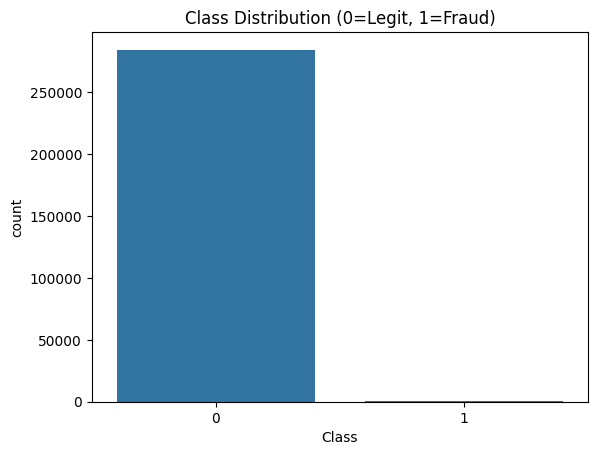

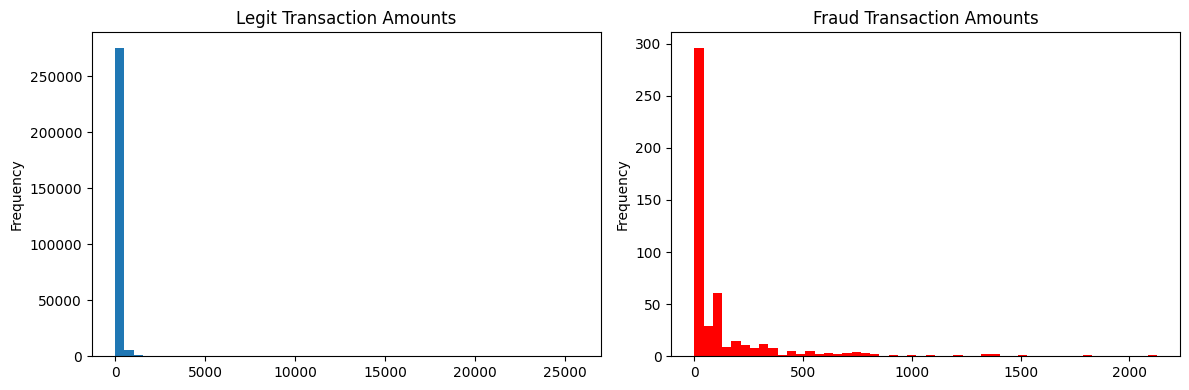

In [3]:
# Class distribution
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0=Legit, 1=Fraud)")
plt.savefig("class_distribution.png")
plt.show()

# Fraud vs legit transaction amount
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
df[df["Class"]==0]["Amount"].plot(ax=ax1, title="Legit Transaction Amounts", bins=50, kind="hist")
df[df["Class"]==1]["Amount"].plot(ax=ax2, title="Fraud Transaction Amounts", bins=50, kind="hist", color="red")
plt.tight_layout()
plt.savefig("amount_distribution.png")
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler

# Scale Amount and Time (other features are already scaled)
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])
df = df.drop(["Amount", "Time"], axis=1)

# Split
X = df.drop("Class", axis=1)
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (227845, 30), Test size: (56962, 30)


In [5]:
# Handle imbalance using class_weight
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    roc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    results[name] = {"ROC-AUC": round(roc, 4)}
    print(f"\n{name}")
    print(classification_report(y_test, preds))

print(pd.DataFrame(results).T)


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

                     ROC-AUC
Logistic Regression   0.9722
Random Forest         0.9530


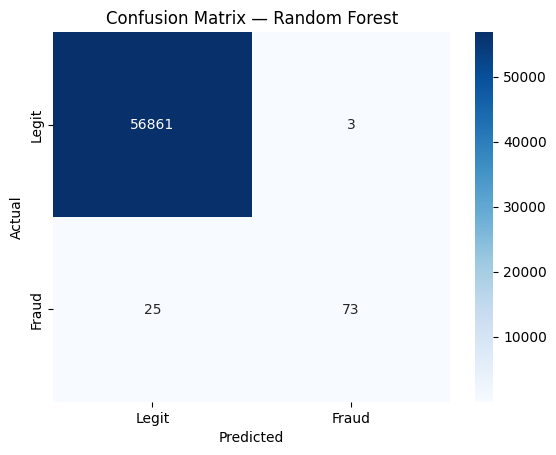

In [6]:
best_model = models["Random Forest"]
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"],
            yticklabels=["Legit", "Fraud"])
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("confusion_matrix.png")
plt.show()

In [7]:
import joblib

joblib.dump(models["Logistic Regression"], "logistic_model.pkl")
joblib.dump(models["Random Forest"], "random_forest_model.pkl")
joblib.dump(scaler, f"scaler.pkl")

print("Models saved.")

Models saved.


In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# StratifiedKFold maintains class ratio in each fold (same idea as stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    print(f"{name}")
    print(f"  ROC-AUC per fold: {scores.round(3)}")
    print(f"  Mean: {scores.mean():.3f} | Std: {scores.std():.3f}")
    print()

Logistic Regression
  ROC-AUC per fold: [0.988 0.983 0.981 0.965 0.981]
  Mean: 0.979 | Std: 0.008

Random Forest
  ROC-AUC per fold: [0.953 0.958 0.963 0.953 0.932]
  Mean: 0.952 | Std: 0.011



## 📊 Cross Validation Results

5-fold stratified cross validation confirms Logistic Regression is both 
more accurate (mean ROC-AUC: 0.979) and more consistent (std: 0.008) 
than Random Forest (mean: 0.952, std: 0.011). LR is the recommended 
model for production fraud detection.

In [ ]:
from xgboost import XGBClassifier

# scale_pos_weight handles imbalance in XGBoost
# it's the equivalent of class_weight='balanced'
# value = number of legit / number of fraud
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    random_state=42,
    eval_metric="auc"
)

# Cross validate
xgb_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring="roc_auc")
print(f"\nXGBoost")
print(f"  ROC-AUC per fold: {xgb_scores.round(3)}")
print(f"  Mean: {xgb_scores.mean():.3f} | Std: {xgb_scores.std():.3f}")